# Feature Engineering con Pipelines de scikit-learn
## Dataset `corazon.csv` — predicción de enfermedad cardíaca

---

### Problema

Clasificación binaria supervisada: predecir la variable `disease`
(`0` = sin enfermedad cardíaca, `1` = con enfermedad cardíaca) a partir de
13 atributos clínicos de cada paciente.

Este notebook documenta y construye **todo el proceso de preparación de datos
como transformadores y pipelines de scikit-learn**, de modo que la misma
secuencia de transformaciones se aplique de forma idéntica y reproducible a los
datos de entrenamiento, a los de prueba y a cualquier dato nuevo en producción.

### Contenido

| Sección | Etapa |
|---|---|
| 1 | Carga y diagnóstico de los datos |
| 2 | **Limpieza de datos** — duplicados, tipos, valores atípicos, faltantes |
| 3 | **Selección de atributos** (Feature Selection) |
| 4 | **Ingeniería de atributos** (Feature Engineering) — discretización, transformaciones, atributos derivados |
| 5 | **Escalado de atributos** (Feature Scaling) |
| 6 | **Encoding** de variables categóricas |
| 7 | Ensamblaje del `ColumnTransformer` y el `Pipeline` completo |
| 8 | Entrenamiento y evaluación del modelo |
| 9 | Verificación final y persistencia del pipeline |

### Principio de diseño que se sigue en todo el notebook

> Las transformaciones que **aprenden parámetros de los datos** (la mediana para
> imputar, la media y la desviación para escalar, las categorías para codificar,
> los cortes para discretizar) **deben ir dentro del pipeline** y ajustarse
> **únicamente con el conjunto de entrenamiento**. Si se calculan sobre todo el
> dataset antes de partir, se produce *data leakage* y la evaluación queda
> optimista y falsa.
>
> Las operaciones que **modifican el número de filas** (eliminar duplicados,
> eliminar filas sin etiqueta) **no pueden ir dentro de un pipeline de
> scikit-learn**, porque un `Pipeline` transforma `X` sin poder alterar `y`, y en
> predicción debe devolver exactamente una salida por cada fila de entrada. Esas
> operaciones se hacen en una etapa previa de saneamiento del dataset.

In [1]:
import warnings

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
np.set_printoptions(suppress=True, linewidth=160)

RANDOM_STATE = 42

# Paleta y estilo consistentes para todas las figuras del notebook
AZUL, NARANJA, AQUA, AMARILLO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA2 = "#0b0b0b", "#52514e"
mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d8d7d2",
        "axes.grid": True,
        "grid.color": "#ebeae5",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": TINTA,
        "axes.labelcolor": TINTA2,
        "xtick.color": TINTA2,
        "ytick.color": TINTA2,
        "axes.titlesize": 11,
        "font.size": 9,
        "figure.dpi": 110,
    }
)

print("scikit-learn:", sklearn.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

# Requisito mínimo de versión: `OneHotEncoder(sparse_output=...)` y
# `FunctionTransformer(feature_names_out=...)` existen desde scikit-learn 1.2.
_version = tuple(int(p) for p in sklearn.__version__.split(".")[:2])
if _version < (1, 2):
    print("\n⚠️  ATENCIÓN: se requiere scikit-learn >= 1.2. Actualiza con:")
    print("    pip install -U scikit-learn")

scikit-learn: 1.9.0 | pandas: 3.0.5 | numpy: 2.5.2


---
# 1. Carga y diagnóstico de los datos

Antes de decidir *qué* limpiar hay que ver *qué está roto*. Se carga el CSV
forzando todas las columnas a texto (`dtype=str`): así pandas no oculta el
problema convirtiendo silenciosamente ni fallando, y podemos ver los valores
basura tal como están en el archivo.

In [2]:
RUTA = "/mnt/c/Users/KATANA/Heart_project/data/01_raw/corazon.csv"

crudo = pd.read_csv(RUTA, dtype=str, keep_default_na=True)
print("Dimensiones del archivo original:", crudo.shape)
crudo.head(10)

Dimensiones del archivo original: (3030, 14)


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0
5,56,Male,nontypical,120,236,0,normal,178,0,0.8,1,0.0,normal,0
6,62,Female,asymptomatic,140,268,0,left ventricular hypertrophy,160,0,3.6,3,2.0,normal,1
7,57,Female,asymptomatic,120,354,0,normal,163,1,0.6,1,0.0,normal,0
8,63,Male,asymptomatic,130,254,0,left ventricular hypertrophy,147,0,1.4,2,1.0,reversable,1
9,53,Male,asymptomatic,140,203,1,left ventricular hypertrophy,155,1,3.1,3,0.0,reversable,1


In [3]:
# Diccionario de datos del dataset (UCI Heart Disease / Cleveland)
diccionario = pd.DataFrame(
    [
        ("age", "Edad del paciente en años", "numérica continua"),
        ("sex", "Sexo biológico (Male / Female)", "categórica binaria"),
        ("chest_pain", "Tipo de dolor torácico", "categórica nominal"),
        ("rest_bp", "Presión arterial en reposo (mm Hg)", "numérica continua"),
        ("chol", "Colesterol sérico (mg/dl)", "numérica continua"),
        ("fbs", "Glucemia en ayunas > 120 mg/dl (1=sí, 0=no)", "binaria"),
        ("rest_ecg", "Resultado del electrocardiograma en reposo", "categórica nominal"),
        ("max_hr", "Frecuencia cardíaca máxima alcanzada", "numérica continua"),
        ("exang", "Angina inducida por ejercicio (1=sí, 0=no)", "binaria"),
        ("old_peak", "Depresión del ST inducida por ejercicio", "numérica continua"),
        ("slope", "Pendiente del segmento ST en ejercicio máximo (1,2,3)", "categórica ordinal"),
        (
            "ca",
            "Nº de vasos principales coloreados por fluoroscopia",
            "numérica discreta / ordinal",
        ),
        ("thal", "Talasemia (normal / fixed / reversable)", "categórica nominal"),
        ("disease", "VARIABLE OBJETIVO: 1 = enfermedad, 0 = sano", "objetivo binaria"),
    ],
    columns=["atributo", "descripción", "tipo"],
)
diccionario

,atributo,descripción,tipo
0,age,Edad del paciente en años,numérica continua
1,sex,Sexo biológico (Male / Female),categórica binaria
2,chest_pain,Tipo de dolor torácico,categórica nominal
3,rest_bp,Presión arterial en reposo (mm Hg),numérica continua
4,chol,Colesterol sérico (mg/dl),numérica continua
5,fbs,"Glucemia en ayunas > 120 mg/dl (1=sí, 0=no)",binaria
6,rest_ecg,Resultado del electrocardiograma en reposo,categórica nominal
7,max_hr,Frecuencia cardíaca máxima alcanzada,numérica continua
8,exang,"Angina inducida por ejercicio (1=sí, 0=no)",binaria
9,old_peak,Depresión del ST inducida por ejercicio,numérica continua


In [4]:
# --- Diagnóstico 1: valores faltantes y duplicados ---------------------------
print(
    "Filas duplicadas exactas :",
    crudo.duplicated().sum(),
    f"({crudo.duplicated().mean():.1%} del total)",
)
print("Filas únicas             :", len(crudo.drop_duplicates()))
print()

faltantes = pd.DataFrame(
    {
        "n_faltantes": crudo.isna().sum(),
        "%_faltantes": (crudo.isna().mean() * 100).round(2),
        "n_valores_unicos": crudo.nunique(),
    }
)
faltantes

Filas duplicadas exactas : 2462 (81.3% del total)
Filas únicas             : 568



,n_faltantes,%_faltantes,n_valores_unicos
age,30,0.99,43
sex,61,2.01,5
chest_pain,83,2.74,7
rest_bp,81,2.67,52
chol,85,2.81,154
fbs,97,3.20,2
rest_ecg,193,6.37,8
max_hr,171,5.64,92
exang,151,4.98,4
old_peak,150,4.95,42


In [5]:
# --- Diagnóstico 2: ¿qué valores no numéricos contaminan las columnas numéricas? ---
COLS_NUMERICAS_ESPERADAS = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca", "fbs"]

print("Valores NO convertibles a número encontrados en columnas numéricas:\n")
for col in COLS_NUMERICAS_ESPERADAS:
    convertido = pd.to_numeric(crudo[col], errors="coerce")
    basura = crudo[col][convertido.isna() & crudo[col].notna()]
    if len(basura):
        print(f"  {col:>10}: {sorted(basura.unique().tolist())}")
    else:
        print(f"  {col:>10}: (ninguno)")

Valores NO convertibles a número encontrados en columnas numéricas:

         age: ['fggfds', 'sdg']
     rest_bp: ['fsgh', 'wety']
        chol: ['sfdywe', 'wtey']
      max_hr: ['adfs']
    old_peak: ['afd', 'asd']
          ca: ['afd']
         fbs: (ninguno)


In [6]:
# --- Diagnóstico 3: categorías válidas vs. valores basura en columnas categóricas ---
COLS_CATEGORICAS = ["sex", "chest_pain", "rest_ecg", "exang", "slope", "thal", "disease"]

for col in COLS_CATEGORICAS:
    print(f"--- {col} ---")
    print(crudo[col].value_counts(dropna=False).to_string())
    print()

--- sex ---
sex
Male      2017
Female     949
NaN         61
2345         1
45           1
765          1

--- chest_pain ---
chest_pain
asymptomatic    1394
nonanginal       840
nontypical       486
typical          224
NaN               83
2345               1
2435               1
3456               1

--- rest_ecg ---
rest_ecg
normal                           1409
left ventricular hypertrophy     1387
NaN                               193
ST-T wave abnormality              36
5678                                1
3563                                1
5653                                1
36653                               1
435647                              1

--- exang ---
exang
0       1929
1        948
NaN      151
f          1
adfs       1

--- slope ---
slope
1      1353
2      1323
3       202
NaN     151
afd       1

--- thal ---
thal
normal        1599
reversable    1129
fixed          172
NaN            126
87654            1
365635463        1
56               1
53646  

### Hallazgos del diagnóstico

El dataset viene deliberadamente sucio. Los problemas detectados son:

1. **Duplicados masivos:** ~81 % de las filas son repeticiones exactas de otras.
   Entrenar así infla artificialmente el tamaño de la muestra y, si los duplicados
   quedan repartidos entre train y test, **el modelo evalúa sobre filas que ya
   memorizó**.
2. **Tipos incorrectos:** todas las columnas llegan como texto porque hay cadenas
   basura mezcladas (`'fggfds'`, `'wety'`, `'afd'`, `'adfs'`…) dentro de columnas
   numéricas.
3. **Categorías inválidas:** códigos numéricos sin sentido (`'2345'`, `'365635463'`,
   `'36653'`) y cadenas basura (`'fsg'`, `'gsfdg'`) en columnas categóricas, incluida
   la variable objetivo.
4. **Espacios sobrantes:** por ejemplo `'left ventricular hypertrophy '` termina en
   espacio; sin normalizar generaría una categoría distinta a la misma sin espacio.
5. **Valores faltantes** en las 14 columnas (entre 1 % y 6,4 %), incluida la
   variable objetivo.

La estrategia frente a la basura: **todo valor no interpretable se convierte en
`NaN`** y a partir de ahí se trata con un único mecanismo uniforme —la
imputación—, en lugar de inventar una regla distinta para cada tipo de error.

---
# 2. Limpieza de datos

Se separa en dos bloques según la regla enunciada al inicio:

* **2.A — Saneamiento a nivel de fila (fuera del pipeline).** Cambia el número de
  filas: parseo de tipos, eliminación de duplicados y de filas sin etiqueta.
  Es una limpieza *del dataset*, no una transformación *del modelo*.
* **2.B — Transformadores de limpieza (dentro del pipeline).** Actúan columna a
  columna sin cambiar el número de filas: normalización de categorías, tratamiento
  de valores atípicos e imputación de faltantes. Aprenden sus parámetros del
  conjunto de entrenamiento.

## 2.A Saneamiento a nivel de fila

### Parseo de tipos y normalización de texto

In [7]:
# Categorías válidas conocidas del dominio. Todo lo que no esté aquí es basura -> NaN
CATEGORIAS_VALIDAS = {
    "sex": ["female", "male"],
    "chest_pain": ["asymptomatic", "nonanginal", "nontypical", "typical"],
    "rest_ecg": ["left ventricular hypertrophy", "normal", "st-t wave abnormality"],
    "exang": ["0", "1"],
    "slope": ["1", "2", "3"],
    "thal": ["fixed", "normal", "reversable"],
    "disease": ["0", "1"],
}
COLS_NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca", "fbs"]
OBJETIVO = "disease"


def sanear_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Convierte tipos y transforma en NaN todo valor no interpretable.

    No elimina filas: sólo corrige tipos y marca la basura como faltante.
    """
    df = df.copy()

    # 1) Columnas numéricas: lo que no sea número -> NaN
    for col in COLS_NUM:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 2) Columnas categóricas: minúsculas, sin espacios sobrantes,
    #    y lo que no esté en el catálogo del dominio -> NaN
    for col, validas in CATEGORIAS_VALIDAS.items():
        s = df[col].astype("string").str.strip().str.lower()
        s = s.str.replace(r"\s+", " ", regex=True)  # espacios internos múltiples
        s = s.where(s.isin(validas), other=pd.NA)
        df[col] = s

    return df


saneado = sanear_dataset(crudo)

print("Tipos después del saneamiento:")
print(saneado.dtypes.to_string())
print(
    "\nValores basura convertidos a NaN:",
    int(saneado.isna().sum().sum() - crudo.isna().sum().sum()),
)

Tipos después del saneamiento:
age           float64
sex            string
chest_pain     string
rest_bp       float64
chol          float64
fbs           float64
rest_ecg       string
max_hr        float64
exang          string
old_peak      float64
slope          string
ca            float64
thal           string
disease        string

Valores basura convertidos a NaN: 33


### Eliminación de registros duplicados

Se eliminan **después** de sanear los tipos: dos filas idénticas escritas de forma
distinta (`'Male'` vs `'male '`) sólo se reconocen como duplicadas una vez
normalizado el texto.

In [8]:
antes = len(saneado)
sin_dup = saneado.drop_duplicates().reset_index(drop=True)
print(f"Antes de eliminar duplicados : {antes:>5} filas")
print(f"Después                      : {len(sin_dup):>5} filas")
print(
    f"Eliminadas                   : {antes - len(sin_dup):>5} filas ({1 - len(sin_dup) / antes:.1%})"
)

Antes de eliminar duplicados :  3030 filas
Después                      :   568 filas
Eliminadas                   :  2462 filas (81.3%)


### Filas sin variable objetivo

Una fila sin etiqueta no sirve para aprendizaje supervisado: no se puede imputar
la respuesta que el modelo debe predecir sin inventar la señal misma. Se eliminan.

In [9]:
sin_objetivo = sin_dup[OBJETIVO].isna().sum()
limpio = sin_dup.dropna(subset=[OBJETIVO]).reset_index(drop=True)
limpio[OBJETIVO] = limpio[OBJETIVO].astype(int)

# Al eliminar filas pueden reaparecer duplicados: se vuelve a comprobar
limpio = limpio.drop_duplicates().reset_index(drop=True)

print(f"Filas sin etiqueta eliminadas: {sin_objetivo}")
print(f"Dataset saneado final        : {limpio.shape}")
print("\nDistribución de la clase objetivo:")
print(limpio[OBJETIVO].value_counts().rename({0: "sano (0)", 1: "enfermo (1)"}).to_string())
print(
    f"\nBalance de clases: {limpio[OBJETIVO].mean():.1%} de casos positivos -> dataset balanceado"
)

Filas sin etiqueta eliminadas: 88
Dataset saneado final        : (480, 14)

Distribución de la clase objetivo:
disease
sano (0)       250
enfermo (1)    230

Balance de clases: 47.9% de casos positivos -> dataset balanceado


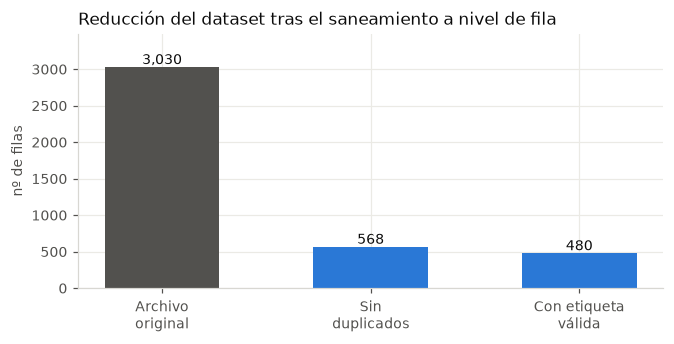

In [10]:
# Resumen visual del efecto del saneamiento sobre el número de filas
etapas = ["Archivo\noriginal", "Sin\nduplicados", "Con etiqueta\nválida"]
valores = [len(crudo), len(sin_dup), len(limpio)]

fig, ax = plt.subplots(figsize=(6.2, 3.2))
barras = ax.bar(etapas, valores, color=[TINTA2, AZUL, AZUL], width=0.55)
for b, v in zip(barras, valores, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 40, f"{v:,}", ha="center", fontsize=9, color=TINTA)
ax.set_ylabel("nº de filas")
ax.set_title("Reducción del dataset tras el saneamiento a nivel de fila", loc="left")
ax.set_ylim(0, max(valores) * 1.15)
plt.tight_layout()
plt.show()

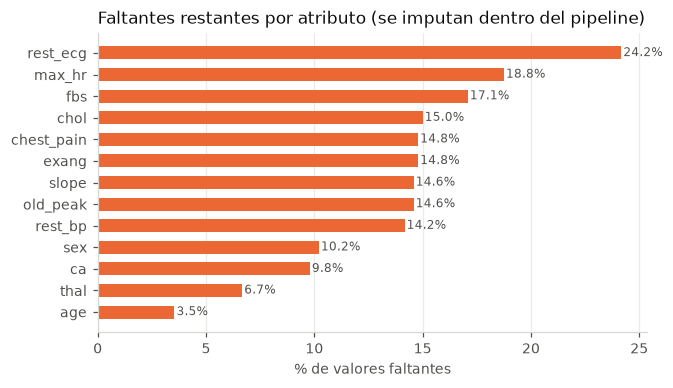

In [11]:
# Valores faltantes que quedan (ya sin duplicados) - los resolverá el pipeline
faltantes_post = (limpio.isna().mean() * 100).sort_values(ascending=False)
faltantes_post = faltantes_post[faltantes_post > 0]

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.barh(faltantes_post.index[::-1], faltantes_post.values[::-1], color=NARANJA, height=0.6)
for i, v in enumerate(faltantes_post.values[::-1]):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8, color=TINTA2)
ax.set_xlabel("% de valores faltantes")
ax.set_title("Faltantes restantes por atributo (se imputan dentro del pipeline)", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Partición train / test

**Se parte aquí, antes de cualquier transformación que aprenda parámetros.**
Todo lo que venga después (imputación, escalado, discretización, encoding) se
ajustará sólo con `X_train` y se aplicará a `X_test`.

Se usa `stratify=y` para conservar la proporción de clases en ambos conjuntos.

In [12]:
X = limpio.drop(columns=[OBJETIVO])
y = limpio[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape}   y_train positivos: {y_train.mean():.1%}")
print(f"X_test : {X_test.shape}   y_test  positivos: {y_test.mean():.1%}")

X_train: (384, 13)   y_train positivos: 47.9%
X_test : (96, 13)   y_test  positivos: 47.9%


## 2.B Transformadores de limpieza (dentro del pipeline)

Se implementan como clases que heredan de `BaseEstimator` y `TransformerMixin`,
la interfaz estándar de scikit-learn. Al implementar `fit`/`transform` (y
`get_feature_names_out`) quedan encajables en cualquier `Pipeline` o
`ColumnTransformer`, y son clonables por `GridSearchCV` y `cross_val_score`.

### Funciones auxiliares de conversión

`FunctionTransformer` envuelve una función cualquiera como transformador de
scikit-learn. Se definen como funciones con nombre (no `lambda`) porque un
`lambda` no es serializable: el pipeline entrenado debe poder guardarse con
`joblib` al final del notebook.

In [13]:
def a_numerico(X):
    """Convierte todas las columnas a float; lo no convertible queda como NaN."""
    return pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)


def a_texto(X):
    """Convierte a texto normalizado (object dtype) usando np.nan para los faltantes.

    Se usa np.nan y no pd.NA porque los transformadores de scikit-learn no
    interpretan el marcador de faltante propio de pandas.
    """
    df = pd.DataFrame(X).astype(object)

    def normalizar(valor):
        return np.nan if pd.isna(valor) else str(valor).strip().lower()

    # DataFrame.map existe desde pandas 2.1; applymap es su equivalente anterior
    aplicar = df.map if hasattr(pd.DataFrame, "map") else df.applymap
    return aplicar(normalizar)


def nombres_log(transformador, nombres):
    """Nombres de salida de la rama logarítmica."""
    return np.array([f"log_{n}" for n in nombres])


def nombres_raiz(transformador, nombres):
    """Nombres de salida de la rama de raíz cuadrada."""
    return np.array([f"sqrt_{n}" for n in nombres])


# Transformadores reutilizables construidos a partir de esas funciones
A_NUMERICO = FunctionTransformer(a_numerico, feature_names_out="one-to-one")
A_TEXTO = FunctionTransformer(a_texto, feature_names_out="one-to-one")

a_texto(pd.DataFrame({"sex": ["Male ", pd.NA], "fbs": [1.0, None]}))

,sex,fbs
0,male,1.0
1,NaN,NaN


### `SaneadorTipos` — parseo defensivo dentro del pipeline

Aunque el dataset ya se saneó arriba, el mismo saneamiento se incluye **también**
como primer paso del pipeline. Motivo: en producción llegarán filas nuevas con la
misma basura, y el pipeline debe ser capaz de digerirlas por sí solo, sin depender
de que alguien haya ejecutado antes un script externo.

In [14]:
class SaneadorTipos(BaseEstimator, TransformerMixin):
    """Convierte a numérico o a categoría válida, marcando como NaN lo no interpretable.

    Parámetros
    ----------
    cols_numericas : list[str]
        Columnas que deben acabar siendo numéricas.
    categorias_validas : dict[str, list[str]]
        Catálogo de categorías admitidas por columna categórica.
    """

    def __init__(self, cols_numericas=None, categorias_validas=None):
        self.cols_numericas = cols_numericas
        self.categorias_validas = categorias_validas

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.cols_numericas or []:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
        for col, validas in (self.categorias_validas or {}).items():
            if col in X.columns:
                s = X[col].astype("string").str.strip().str.lower()
                s = s.str.replace(r"\s+", " ", regex=True)
                X[col] = s.where(s.isin(validas), other=pd.NA)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_ if input_features is None else input_features)


# Comprobación rápida sobre datos crudos con basura
demo = pd.DataFrame({"age": ["63", "fggfds", None], "sex": ["Male", "2345", " female "]})
SaneadorTipos(cols_numericas=["age"], categorias_validas={"sex": ["female", "male"]}).fit_transform(
    demo
)

,age,sex
0,63.0,male
1,NaN,<NA>
2,NaN,female


### `RecortadorAtipicos` — tratamiento de valores atípicos

**Decisión de diseño.** Existen tres opciones frente a un valor atípico:

| Opción | Cuándo tiene sentido | Aquí |
|---|---|---|
| Eliminar la fila | El atípico es un error de medición evidente | ❌ cambia el nº de filas → imposible en un pipeline, y en predicción no se puede descartar un paciente |
| Aislarlo como señal | El problema *es* la detección de anomalías | ❌ no es el caso: el problema es clasificación diagnóstica |
| **Recortar (winsorizing)** | El atípico es un valor real pero extremo, que no queremos que domine el modelo | ✅ **elegido** |

Un colesterol de 564 mg/dl es clínicamente **real** y probablemente informativo:
eliminar a ese paciente destruiría información diagnóstica valiosa. Se recorta a
los límites de Tukey (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`) para acotar su influencia
sin perder la fila ni el hecho de que es un valor alto.

Los límites se calculan en `fit` (sólo con train) y se reutilizan tal cual en
`transform` sobre test.

In [15]:
class RecortadorAtipicos(BaseEstimator, TransformerMixin):
    """Winsoriza cada columna numérica a los límites de Tukey aprendidos en fit.

    Parámetros
    ----------
    factor : float
        Multiplicador del IQR. 1.5 = criterio clásico de Tukey; 3.0 = sólo extremos.
    metodo : {'iqr', 'percentil'}
        'iqr' usa Q1-k*IQR / Q3+k*IQR; 'percentil' usa los cuantiles 1% y 99%.
    """

    def __init__(self, factor=1.5, metodo="iqr"):
        self.factor = factor
        self.metodo = metodo

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.nombres_entrada_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        Xn = X.apply(pd.to_numeric, errors="coerce").astype(float)

        if self.metodo == "iqr":
            q1, q3 = Xn.quantile(0.25), Xn.quantile(0.75)
            iqr = q3 - q1
            self.limite_inferior_ = (q1 - self.factor * iqr).to_numpy(dtype=float)
            self.limite_superior_ = (q3 + self.factor * iqr).to_numpy(dtype=float)
        else:
            self.limite_inferior_ = Xn.quantile(0.01).to_numpy(dtype=float)
            self.limite_superior_ = Xn.quantile(0.99).to_numpy(dtype=float)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)
        return X.clip(lower=self.limite_inferior_, upper=self.limite_superior_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.nombres_entrada_ if input_features is None else input_features)

In [16]:
# ¿Cuántos atípicos hay y qué efecto tiene el recorte?
NUM_CONTINUAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]

train_num = a_numerico(X_train[NUM_CONTINUAS])
recortador = RecortadorAtipicos(factor=1.5).fit(train_num)

resumen = pd.DataFrame(
    {
        "límite_inf": recortador.limite_inferior_,
        "límite_sup": recortador.limite_superior_,
        "n_atípicos": [
            int(((train_num[c] < li) | (train_num[c] > ls)).sum())
            for c, li, ls in zip(
                NUM_CONTINUAS, recortador.limite_inferior_, recortador.limite_superior_, strict=True
            )
        ],
    },
    index=NUM_CONTINUAS,
).round(2)
resumen["%_atípicos"] = (resumen["n_atípicos"] / len(train_num) * 100).round(2)
resumen

,límite_inf,límite_sup,n_atípicos,%_atípicos
age,28.5,80.5,0,0.00
rest_bp,90.0,170.0,8,2.08
chol,104.5,388.5,5,1.30
max_hr,95.5,205.5,3,0.78
old_peak,-2.4,4.0,4,1.04


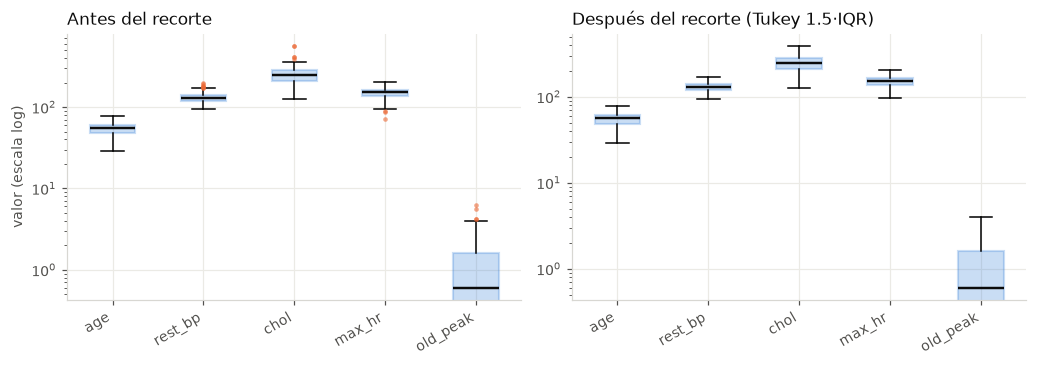

In [17]:
recortado = recortador.transform(train_num)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=False)
for ax, datos, titulo in zip(
    axes,
    [train_num, recortado],
    ["Antes del recorte", "Después del recorte (Tukey 1.5·IQR)"],
    strict=True,
):
    bp = ax.boxplot(
        [datos[c].dropna() for c in NUM_CONTINUAS],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color=TINTA, linewidth=1.6),
        flierprops=dict(
            marker="o", markersize=3, markerfacecolor=NARANJA, markeredgecolor="none", alpha=0.6
        ),
    )
    for caja in bp["boxes"]:
        caja.set(facecolor=AZUL, alpha=0.25, edgecolor=AZUL, linewidth=1.4)
    ax.set_yscale("log")
    ax.set_title(titulo, loc="left")
    ax.set_xticks(range(1, len(NUM_CONTINUAS) + 1), NUM_CONTINUAS, rotation=30, ha="right")
axes[0].set_ylabel("valor (escala log)")
plt.tight_layout()
plt.show()

### Imputación de valores faltantes

Se usan estrategias distintas según la naturaleza del atributo, porque la media
de una variable categórica no significa nada:

| Grupo | Estrategia | Justificación |
|---|---|---|
| Numéricas continuas | **mediana** | robusta frente a los valores extremos que acabamos de detectar; la media se desplazaría con un colesterol de 564 |
| Binarias / ordinales | **más frecuente** | conserva un valor válido del dominio (no genera un 0,37 imposible) |
| Categóricas nominales | **más frecuente** | ídem; alternativa razonable sería una categoría explícita `"desconocido"` |

Los valores de imputación se aprenden en `fit` sobre train y se reutilizan en test.
Se activa `add_indicator=True` en las continuas: añade una columna binaria que
marca *dónde faltaba el dato*, porque la ausencia de una medición clínica puede ser
en sí misma informativa.

In [18]:
# Demostración aislada del imputador antes de integrarlo
imputador_demo = SimpleImputer(strategy="median", add_indicator=True)
antes_na = a_numerico(X_train[NUM_CONTINUAS])
despues = imputador_demo.fit_transform(antes_na)

print("Medianas aprendidas del conjunto de ENTRENAMIENTO:")
for c, m in zip(NUM_CONTINUAS, imputador_demo.statistics_, strict=True):
    print(f"  {c:>10}: {m:.2f}")
print(
    f"\nNaN antes: {int(antes_na.isna().sum().sum())}  ->  NaN después: {int(np.isnan(despues).sum())}"
)
print(
    f"Columnas: {len(NUM_CONTINUAS)} -> {despues.shape[1]}  (las extra son los indicadores de faltante)"
)

Medianas aprendidas del conjunto de ENTRENAMIENTO:
         age: 56.00
     rest_bp: 130.00
        chol: 245.00
      max_hr: 152.00
    old_peak: 0.60

NaN antes: 237  ->  NaN después: 0
Columnas: 5 -> 10  (las extra son los indicadores de faltante)


---
# 3. Selección de atributos (Feature Selection)

Objetivo: descartar atributos que no aportan información útil. Se examinan tres
criterios antes de decidir.

In [19]:
# Criterio 1: varianza casi nula -> una columna casi constante no discrimina nada
temp = X_train.copy()
temp[COLS_NUM] = a_numerico(X_train[COLS_NUM])

varianzas = temp[COLS_NUM].var().sort_values()
print("Varianza de los atributos numéricos:")
print(varianzas.round(3).to_string())
print("\nCardinalidad de los categóricos (1 valor único = inútil):")
print(X_train[["sex", "chest_pain", "rest_ecg", "exang", "slope", "thal"]].nunique().to_string())

Varianza de los atributos numéricos:
fbs            0.130
ca             0.848
old_peak       1.336
age           73.875
rest_bp      296.438
max_hr       509.192
chol        2983.851

Cardinalidad de los categóricos (1 valor único = inútil):
sex           2
chest_pain    4
rest_ecg      3
exang         2
slope         3
thal          3


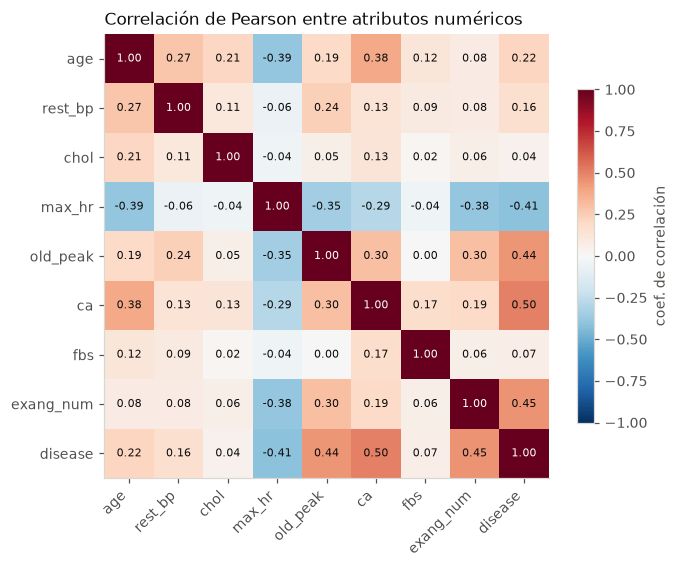

Correlación con la variable objetivo (ordenada por magnitud):
ca           0.503
exang_num    0.452
old_peak     0.442
max_hr       0.410
age          0.218
rest_bp      0.162
fbs          0.070
chol         0.042


In [20]:
# Criterio 2: correlación con la variable objetivo e intercorrelación entre atributos
aux = temp[COLS_NUM].copy()
aux["exang_num"] = a_numerico(X_train[["exang"]])["exang"]
aux["disease"] = y_train.values

corr = aux.corr(numeric_only=True)

UMBRAL_TEXTO_CLARO = 0.55  # a partir de esta correlación el texto se pinta en blanco

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=7.5,
            color="white" if abs(v) > UMBRAL_TEXTO_CLARO else TINTA,
        )
ax.set_title("Correlación de Pearson entre atributos numéricos", loc="left")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="coef. de correlación")
plt.tight_layout()
plt.show()

print("Correlación con la variable objetivo (ordenada por magnitud):")
print(corr["disease"].drop("disease").abs().sort_values(ascending=False).round(3).to_string())

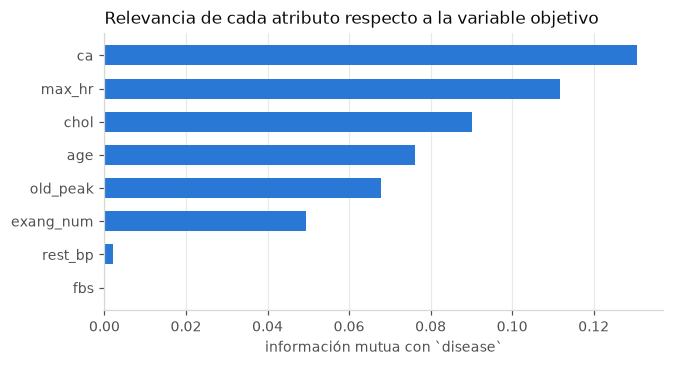

In [21]:
# Criterio 3: información mutua (captura relaciones NO lineales, a diferencia de Pearson)
aux_mi = aux.drop(columns=["disease"]).astype(float)
aux_mi = aux_mi.fillna(aux_mi.median())
mi = pd.Series(
    mutual_info_classif(aux_mi, y_train, random_state=RANDOM_STATE),
    index=aux_mi.columns,
).sort_values()

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.barh(mi.index, mi.values, color=AZUL, height=0.6)
ax.set_xlabel("información mutua con `disease`")
ax.set_title("Relevancia de cada atributo respecto a la variable objetivo", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Decisión sobre la selección de atributos

**No se descarta ningún atributo.** Razones:

* Ningún atributo tiene varianza cero ni cardinalidad 1.
* La correlación máxima entre atributos es moderada (|r| < 0,6): no hay pares
  redundantes que justifiquen eliminar uno.
* Todos los atributos son variables clínicas con relevancia médica reconocida para
  el diagnóstico coronario, y todos muestran información mutua > 0 con la clase.
* Con sólo 13 atributos y varios cientos de filas no hay problema de
  dimensionalidad que obligue a recortar.

No obstante, **se deja la selección integrada como paso opcional del pipeline**
(`VarianceThreshold` + `SelectKBest`) para que sea ajustable por validación cruzada
—`k='all'` desactiva el filtro, y `GridSearchCV` puede explorar otros valores.

In [22]:
# Paso de selección incluido en el pipeline, parametrizable por GridSearchCV
selector_atributos = Pipeline(
    [
        ("umbral_varianza", VarianceThreshold(threshold=0.0)),  # descarta columnas constantes
        ("mejores_k", SelectKBest(score_func=mutual_info_classif, k="all")),
    ]
)
selector_atributos

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('umbral_varianza', ...), ('mejores_k', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...x795f7778b6a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",'all'


---
# 4. Ingeniería de atributos (Feature Engineering)

Tres familias de atributos nuevos:

1. **Discretización** de atributos continuos en intervalos.
2. **Transformaciones matemáticas** (`log`, `sqrt`, `x²`, Yeo-Johnson) para corregir asimetría.
3. **Atributos derivados** del conocimiento del dominio clínico.

## 4.1 Discretización de atributos continuos

Discretizar convierte una variable continua en intervalos. Es útil cuando la
relación con la clase **no es monótona**: el riesgo cardíaco no crece de forma
lineal con la edad, sino a saltos por franjas etarias. Un modelo lineal no puede
capturar eso con la variable continua, pero sí con los intervalos codificados.

Se usa `KBinsDiscretizer` con `strategy='quantile'`, que produce intervalos con
aproximadamente el mismo número de observaciones cada uno (evita intervalos vacíos
en las colas).

In [23]:
discretizador_demo = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
edad_train = a_numerico(X_train[["age"]])
edad_train_imp = SimpleImputer(strategy="median").fit_transform(edad_train)
bins_edad = discretizador_demo.fit_transform(edad_train_imp)

cortes = discretizador_demo.bin_edges_[0]
print("Cortes aprendidos para `age`:", np.round(cortes, 1))

tabla_bins = pd.DataFrame({"intervalo": bins_edad.ravel().astype(int), "disease": y_train.values})
resumen_bins = tabla_bins.groupby("intervalo").agg(
    n=("disease", "size"), tasa_enfermedad=("disease", "mean")
)
resumen_bins["rango_edad"] = [f"{cortes[i]:.0f} a {cortes[i + 1]:.0f}" for i in resumen_bins.index]
resumen_bins.round(3)

Cortes aprendidos para `age`: [29. 46. 54. 57. 62. 77.]


,n,tasa_enfermedad,rango_edad
intervalo,,,
0,69,0.304,29 a 46
1,84,0.345,46 a 54
2,55,0.400,54 a 57
3,90,0.711,57 a 62
4,86,0.558,62 a 77


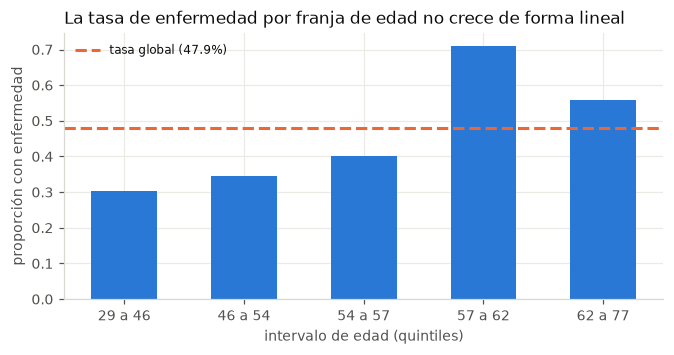

In [24]:
fig, ax = plt.subplots(figsize=(6.2, 3.3))
ax.bar(resumen_bins["rango_edad"], resumen_bins["tasa_enfermedad"], color=AZUL, width=0.55)
ax.axhline(
    y_train.mean(),
    color=NARANJA,
    linewidth=2,
    linestyle="--",
    label=f"tasa global ({y_train.mean():.1%})",
)
ax.set_ylabel("proporción con enfermedad")
ax.set_xlabel("intervalo de edad (quintiles)")
ax.set_title("La tasa de enfermedad por franja de edad no crece de forma lineal", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 4.2 Transformaciones matemáticas

Muchos modelos (regresión logística, SVM, redes) funcionan mejor con atributos
aproximadamente simétricos. Se mide la asimetría (*skewness*) de cada atributo
continuo y se comparan las transformaciones candidatas.

In [25]:
num_train = a_numerico(X_train[NUM_CONTINUAS])
num_train_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(num_train), columns=NUM_CONTINUAS
)

comparacion = pd.DataFrame(
    {
        "original": num_train_imp.skew(),
        "log1p(x)": np.log1p(num_train_imp).skew(),
        "sqrt(x)": np.sqrt(num_train_imp).skew(),
        "x^2": (num_train_imp**2).skew(),
        "Yeo-Johnson": pd.DataFrame(
            PowerTransformer(method="yeo-johnson").fit_transform(num_train_imp),
            columns=NUM_CONTINUAS,
        ).skew(),
    }
).round(3)
comparacion["mejor"] = comparacion.abs().idxmin(axis=1)
comparacion

,original,log1p(x),sqrt(x),x^2,Yeo-Johnson,mejor
age,-0.214,-0.584,-0.397,0.137,-0.044,Yeo-Johnson
rest_bp,0.743,0.281,0.505,1.262,-0.009,Yeo-Johnson
chol,1.471,0.124,0.720,3.693,-0.014,Yeo-Johnson
max_hr,-0.670,-1.212,-0.930,-0.200,-0.011,Yeo-Johnson
old_peak,1.482,0.533,0.200,3.931,0.125,Yeo-Johnson


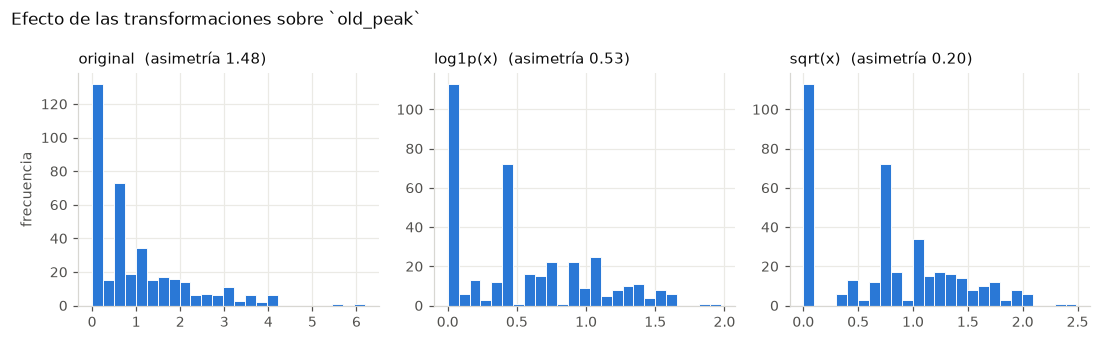

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.1))
serie = num_train_imp["old_peak"]
for ax, (datos, titulo) in zip(
    axes,
    [
        (serie, f"original  (asimetría {serie.skew():.2f})"),
        (np.log1p(serie), f"log1p(x)  (asimetría {np.log1p(serie).skew():.2f})"),
        (np.sqrt(serie), f"sqrt(x)  (asimetría {np.sqrt(serie).skew():.2f})"),
    ],
    strict=True,
):
    ax.hist(datos, bins=25, color=AZUL, edgecolor="white", linewidth=0.6)
    ax.set_title(titulo, loc="left", fontsize=9.5)
axes[0].set_ylabel("frecuencia")
fig.suptitle("Efecto de las transformaciones sobre `old_peak`", x=0.005, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

`old_peak` y `chol` son las más asimétricas. Se aplica **Yeo-Johnson**, que
selecciona automáticamente por máxima verosimilitud el exponente que más
normaliza cada columna y —a diferencia de Box-Cox y de `log`— admite ceros y
valores negativos (`old_peak` tiene ceros).

Además, las transformaciones `log1p` y `sqrt` se añaden como **atributos extra**
mediante `FunctionTransformer`, sin sustituir a los originales: el modelo decide
cuál usar.

In [27]:
# FunctionTransformer: envuelve una función arbitraria como transformador de sklearn
transformador_log = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,  # permite deshacer la transformación
    feature_names_out=nombres_log,
    validate=True,
)
transformador_raiz = FunctionTransformer(
    func=np.sqrt,
    inverse_func=np.square,
    feature_names_out=nombres_raiz,
    validate=True,
)

prueba = transformador_log.fit_transform(num_train_imp[["chol", "old_peak"]])
print("Nombres de salida:", transformador_log.get_feature_names_out(["chol", "old_peak"]))
print("Primeras filas:\n", np.round(prueba[:3], 3))

Nombres de salida: ['log_chol' 'log_old_peak']
Primeras filas:
 [[5.505 0.47 ]
 [5.704 0.47 ]
 [5.308 0.588]]


## 4.3 Atributos derivados del dominio clínico

Se crean combinando atributos existentes según conocimiento médico. Son los que
más valor suelen aportar, porque incorporan información que no está en ninguna
columna por separado:

| Atributo nuevo | Fórmula | Significado clínico |
|---|---|---|
| `fc_maxima_teorica` | `220 − edad` | frecuencia cardíaca máxima esperada por edad |
| `reserva_cardiaca` | `max_hr − (220 − edad)` | cuánto se aleja el paciente de su máximo esperado; muy negativo = respuesta cronotrópica deficiente |
| `pct_fc_alcanzada` | `max_hr / (220 − edad)` | la misma idea, en proporción |
| `ratio_chol_edad` | `chol / edad` | colesterol relativo a la edad |
| `presion_x_chol` | `rest_bp · chol / 1000` | carga de riesgo combinada presión–colesterol |
| `indice_riesgo_st` | `old_peak · (slope − 1)` | interacción entre magnitud y forma de la depresión del ST |

In [28]:
class AtributosClinicos(BaseEstimator, TransformerMixin):
    """Genera atributos derivados a partir del conocimiento del dominio.

    Espera un DataFrame con las columnas age, max_hr, chol, rest_bp, old_peak, slope.

    Parámetros
    ----------
    incluir_interacciones : bool
        Si es False, sólo genera los atributos derivados de la frecuencia cardíaca.
        Se deja como hiperparámetro para poder validarlo con GridSearchCV.
    """

    def __init__(self, incluir_interacciones=True):
        self.incluir_interacciones = incluir_interacciones

    def fit(self, X, y=None):
        self.nombres_entrada_ = np.asarray(pd.DataFrame(X).columns)
        self.n_features_in_ = len(self.nombres_entrada_)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        def num(columna):
            """Devuelve una columna convertida a número."""
            return pd.to_numeric(X[columna], errors="coerce")

        edad, fc_max = num("age"), num("max_hr")
        fc_teorica = 220 - edad

        nuevas = pd.DataFrame(index=X.index)
        nuevas["fc_maxima_teorica"] = fc_teorica
        nuevas["reserva_cardiaca"] = fc_max - fc_teorica
        nuevas["pct_fc_alcanzada"] = fc_max / fc_teorica.replace(0, np.nan)

        if self.incluir_interacciones:
            colesterol, presion = num("chol"), num("rest_bp")
            nuevas["ratio_chol_edad"] = colesterol / edad.replace(0, np.nan)
            nuevas["presion_x_chol"] = presion * colesterol / 1000.0
            nuevas["indice_riesgo_st"] = num("old_peak") * (
                pd.to_numeric(X["slope"], errors="coerce") - 1
            )

        self.nombres_salida_ = np.asarray(nuevas.columns)
        return nuevas.to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        base = ["fc_maxima_teorica", "reserva_cardiaca", "pct_fc_alcanzada"]
        if self.incluir_interacciones:
            base += ["ratio_chol_edad", "presion_x_chol", "indice_riesgo_st"]
        return np.asarray(base)


generador = AtributosClinicos().fit(X_train)
demo_nuevos = pd.DataFrame(generador.transform(X_train), columns=generador.get_feature_names_out())
demo_nuevos.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fc_maxima_teorica,370.0,165.30,8.60,143.00,159.00,164.00,172.00,191.00
reserva_cardiaca,309.0,-15.87,20.72,-82.00,-27.00,-11.00,0.00,29.00
pct_fc_alcanzada,309.0,0.90,0.13,0.46,0.84,0.93,1.00,1.17
ratio_chol_edad,315.0,4.64,1.11,2.10,3.83,4.48,5.31,8.42
presion_x_chol,326.0,32.98,8.77,15.23,26.55,32.29,38.47,64.86
indice_riesgo_st,329.0,0.97,1.68,0.00,0.00,0.00,1.40,12.40


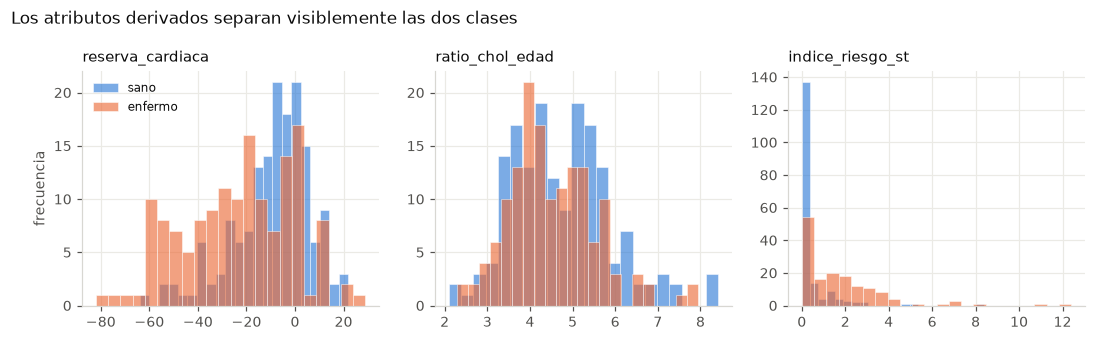

In [29]:
# ¿Los atributos nuevos discriminan? Comparación de distribuciones por clase
fig, axes = plt.subplots(1, 3, figsize=(10, 3.1))
for ax, col in zip(axes, ["reserva_cardiaca", "ratio_chol_edad", "indice_riesgo_st"], strict=True):
    for clase, color, etiqueta in [(0, AZUL, "sano"), (1, NARANJA, "enfermo")]:
        datos = demo_nuevos.loc[y_train.values == clase, col].dropna()
        ax.hist(
            datos,
            bins=22,
            alpha=0.62,
            color=color,
            label=etiqueta,
            edgecolor="white",
            linewidth=0.5,
        )
    ax.set_title(col, loc="left", fontsize=9.5)
axes[0].set_ylabel("frecuencia")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(
    "Los atributos derivados separan visiblemente las dos clases", x=0.005, ha="left", fontsize=11
)
plt.tight_layout()
plt.show()

---
# 5. Escalado de atributos (Feature Scaling)

`chol` va de 126 a 564 y `old_peak` de 0 a 6,2. Sin escalar, los algoritmos
basados en distancias (KNN, SVM) o en gradiente (regresión logística, redes) dan
un peso desproporcionado a la variable de mayor rango.

| Escalador | Fórmula | Cuándo usarlo |
|---|---|---|
| `StandardScaler` | `(x − μ) / σ` | uso general; asume distribución aproximadamente simétrica |
| `MinMaxScaler` | `(x − min) / (max − min)` | cuando se necesita un rango acotado [0,1] (redes neuronales, imágenes) |
| `RobustScaler` | `(x − mediana) / IQR` | con atípicos presentes: usa estadísticos robustos |
| `PowerTransformer` | Yeo-Johnson + estandarización | cuando además hay que corregir asimetría |

**Elección:** `StandardScaler` para los atributos continuos —los atípicos ya se
recortaron en la etapa de limpieza, de modo que la media y la desviación ya no
están distorsionadas— y `PowerTransformer` para los dos atributos más asimétricos.
El escalador se deja como hiperparámetro para poder compararlos por validación
cruzada.

In [30]:
comparar = pd.DataFrame(
    {
        "original": num_train_imp["chol"],
        "StandardScaler": StandardScaler().fit_transform(num_train_imp[["chol"]]).ravel(),
        "MinMaxScaler": MinMaxScaler().fit_transform(num_train_imp[["chol"]]).ravel(),
        "RobustScaler": RobustScaler().fit_transform(num_train_imp[["chol"]]).ravel(),
        "PowerTransformer": PowerTransformer().fit_transform(num_train_imp[["chol"]]).ravel(),
    }
)
comparar.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
original,249.128,50.579,126.000,564.000
StandardScaler,0.000,1.001,-2.438,6.234
MinMaxScaler,0.281,0.115,0.000,1.000
RobustScaler,0.078,0.959,-2.256,6.047
PowerTransformer,0.000,1.001,-3.548,4.106


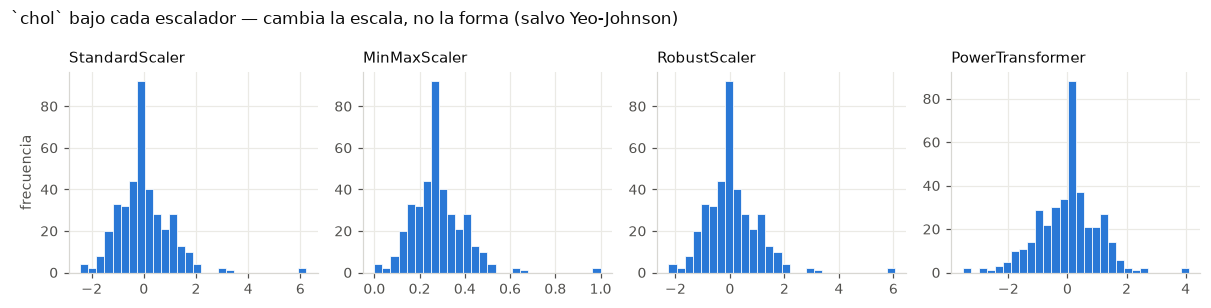

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
for ax, col in zip(
    axes,
    ["StandardScaler", "MinMaxScaler", "RobustScaler", "PowerTransformer"],
    strict=True,
):
    ax.hist(comparar[col], bins=28, color=AZUL, edgecolor="white", linewidth=0.5)
    ax.set_title(col, loc="left", fontsize=9.5)
axes[0].set_ylabel("frecuencia")
fig.suptitle(
    "`chol` bajo cada escalador — cambia la escala, no la forma (salvo Yeo-Johnson)",
    x=0.005,
    ha="left",
    fontsize=11,
)
plt.tight_layout()
plt.show()

---
# 6. Encoding de variables categóricas

Ningún estimador de scikit-learn acepta texto. Cada tipo de variable categórica
requiere una codificación distinta:

| Tipo | Atributos | Codificación | Por qué |
|---|---|---|---|
| **Nominal** (sin orden) | `chest_pain`, `rest_ecg`, `thal` | `OneHotEncoder` | asignar 1, 2, 3 impondría un orden inexistente: el modelo asumiría que `typical` > `asymptomatic` |
| **Binaria** | `sex`, `exang`, `fbs` | `OrdinalEncoder` (equivale a one-hot con `drop='first'`) | con dos categorías una sola columna 0/1 basta; una segunda sería redundante |
| **Ordinal** (con orden real) | `slope`, `ca` | `OrdinalEncoder` con orden explícito | la pendiente del ST y el nº de vasos sí tienen orden natural; conservarlo aporta información |

Parámetros clave de `OneHotEncoder`:

* `handle_unknown='infrequent_if_exist'` — si en producción aparece una categoría
  nunca vista, la agrupa en `infrequent` en lugar de lanzar una excepción.
* `min_frequency=0.01` — agrupa las categorías con menos del 1 % de presencia,
  evitando columnas casi vacías que producen sobreajuste.
* `sparse_output=False` — devuelve un array denso, más cómodo de inspeccionar aquí.

In [32]:
NOMINALES = ["chest_pain", "rest_ecg", "thal"]

codificador_onehot = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=0.01,
    sparse_output=False,
)

cat_train = SimpleImputer(strategy="most_frequent").fit_transform(a_texto(X_train[NOMINALES]))
onehot = codificador_onehot.fit_transform(cat_train)

print(f"{len(NOMINALES)} columnas nominales -> {onehot.shape[1]} columnas codificadas\n")
print("Nombres generados:")
for n in codificador_onehot.get_feature_names_out(NOMINALES):
    print("  ", n)
pd.DataFrame(onehot[:5], columns=codificador_onehot.get_feature_names_out(NOMINALES)).astype(int)

3 columnas nominales -> 10 columnas codificadas

Nombres generados:
   chest_pain_asymptomatic
   chest_pain_nonanginal
   chest_pain_nontypical
   chest_pain_typical
   rest_ecg_left ventricular hypertrophy
   rest_ecg_normal
   rest_ecg_infrequent_sklearn
   thal_fixed
   thal_normal
   thal_reversable


,chest_pain_asymptomatic,chest_pain_nonanginal,chest_pain_nontypical,chest_pain_typical,rest_ecg_left ventricular hypertrophy,rest_ecg_normal,rest_ecg_infrequent_sklearn,thal_fixed,thal_normal,thal_reversable
0,1,0,0,0,1,0,0,1,0,0
1,1,0,0,0,1,0,0,0,0,1
2,0,0,1,0,0,1,0,0,1,0
3,1,0,0,0,0,1,0,0,0,1
4,1,0,0,0,0,1,0,0,0,1


In [33]:
BINARIAS = ["sex", "exang"]
ORDINALES = ["slope"]

codificador_binario = OrdinalEncoder(
    categories=[["female", "male"], ["0", "1"]],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)
codificador_ordinal = OrdinalEncoder(
    categories=[["1", "2", "3"]],  # orden explícito: pendiente ascendente, plana, descendente
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

bin_train = SimpleImputer(strategy="most_frequent").fit_transform(a_texto(X_train[BINARIAS]))
ord_train = SimpleImputer(strategy="most_frequent").fit_transform(a_texto(X_train[ORDINALES]))

print("Binarias codificadas:")
print(
    pd.DataFrame(codificador_binario.fit_transform(bin_train), columns=BINARIAS)
    .head()
    .astype(int)
    .to_string()
)
print("\nOrdinal `slope` codificada (se preserva el orden 1 < 2 < 3):")
print(
    pd.DataFrame(codificador_ordinal.fit_transform(ord_train), columns=ORDINALES)
    .head()
    .astype(int)
    .to_string()
)

Binarias codificadas:
   sex  exang
0    1      0
1    1      0
2    1      0
3    1      0
4    1      0

Ordinal `slope` codificada (se preserva el orden 1 < 2 < 3):
   slope
0      0
1      0
2      0
3      1
4      0


---
# 7. Ensamblaje: `ColumnTransformer` y `Pipeline` completo

Ahora se juntan todas las piezas. La arquitectura es:

```
Pipeline
├── saneador                → parseo defensivo de tipos (todas las columnas)
├── preprocesador  (ColumnTransformer, ramas en paralelo por tipo de dato)
│   ├── continuas   : recorte de atípicos → imputación mediana(+indicador) → Yeo-Johnson → StandardScaler
│   ├── extra_log   : imputación mediana → log1p → StandardScaler
│   ├── extra_raiz  : imputación mediana → sqrt  → StandardScaler
│   ├── discretas   : imputación mediana → KBinsDiscretizer(quantile, one-hot)
│   ├── derivadas   : AtributosClinicos → imputación mediana → StandardScaler
│   ├── binarias    : imputación moda → OrdinalEncoder
│   ├── ordinales   : imputación moda → OrdinalEncoder(orden explícito)
│   ├── nominales   : imputación moda → OneHotEncoder
│   └── conteo (ca) : imputación mediana → StandardScaler
├── selector       → VarianceThreshold + SelectKBest
└── modelo         → clasificador
```

Cada rama del `ColumnTransformer` recibe sólo sus columnas y las procesa en
paralelo; las salidas se concatenan horizontalmente. `remainder='drop'` garantiza
que ninguna columna se cuele sin transformar.

In [34]:
# ---------------------------------------------------------------- grupos de columnas
CONTINUAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]  # numéricas continuas
ASIMETRICAS = ["chol", "old_peak"]  # candidatas a log / sqrt
DISCRETIZAR = ["age", "chol", "max_hr"]  # se convierten en intervalos
CONTEO = ["ca"]  # nº de vasos: discreta 0-3
BINARIAS = ["sex", "exang", "fbs"]
ORDINALES = ["slope"]
NOMINALES = ["chest_pain", "rest_ecg", "thal"]
DERIVADAS_IN = ["age", "max_hr", "chol", "rest_bp", "old_peak", "slope"]  # entradas del generador

# ---------------------------------------------------------------- ramas del preprocesador
rama_continuas = Pipeline(
    [
        ("atipicos", RecortadorAtipicos(factor=1.5, metodo="iqr")),
        ("imputador", SimpleImputer(strategy="median", add_indicator=True)),
        ("potencia", PowerTransformer(method="yeo-johnson", standardize=False)),
        ("escalador", StandardScaler()),
    ]
)

rama_log = Pipeline(
    [
        ("numerico", clone(A_NUMERICO)),
        ("imputador", SimpleImputer(strategy="median")),
        (
            "log",
            FunctionTransformer(
                np.log1p, inverse_func=np.expm1, validate=True, feature_names_out=nombres_log
            ),
        ),
        ("escalador", StandardScaler()),
    ]
)

rama_raiz = Pipeline(
    [
        ("numerico", clone(A_NUMERICO)),
        ("imputador", SimpleImputer(strategy="median")),
        (
            "raiz",
            FunctionTransformer(
                np.sqrt, inverse_func=np.square, validate=True, feature_names_out=nombres_raiz
            ),
        ),
        ("escalador", StandardScaler()),
    ]
)

rama_discretizacion = Pipeline(
    [
        ("numerico", clone(A_NUMERICO)),
        ("imputador", SimpleImputer(strategy="median")),
        ("intervalos", KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy="quantile")),
    ]
)

rama_derivadas = Pipeline(
    [
        ("generador", AtributosClinicos(incluir_interacciones=True)),
        ("imputador", SimpleImputer(strategy="median")),
        ("atipicos", RecortadorAtipicos(factor=3.0, metodo="iqr")),
        ("escalador", StandardScaler()),
    ]
)

rama_conteo = Pipeline(
    [
        ("numerico", clone(A_NUMERICO)),
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", MinMaxScaler()),
    ]
)

rama_binarias = Pipeline(
    [
        ("texto", clone(A_TEXTO)),
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificar", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]
)

rama_ordinales = Pipeline(
    [
        ("texto", clone(A_TEXTO)),
        ("imputador", SimpleImputer(strategy="most_frequent")),
        (
            "codificar",
            OrdinalEncoder(
                categories=[["1", "2", "3"]], handle_unknown="use_encoded_value", unknown_value=-1
            ),
        ),
        ("escalador", MinMaxScaler()),
    ]
)

rama_nominales = Pipeline(
    [
        ("texto", clone(A_TEXTO)),
        ("imputador", SimpleImputer(strategy="most_frequent")),
        (
            "codificar",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False
            ),
        ),
    ]
)

# ---------------------------------------------------------------- ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        ("continuas", rama_continuas, CONTINUAS),
        ("log", rama_log, ASIMETRICAS),
        ("raiz", rama_raiz, ASIMETRICAS),
        ("discretas", rama_discretizacion, DISCRETIZAR),
        ("derivadas", rama_derivadas, DERIVADAS_IN),
        ("conteo", rama_conteo, CONTEO),
        ("binarias", rama_binarias, BINARIAS),
        ("ordinales", rama_ordinales, ORDINALES),
        ("nominales", rama_nominales, NOMINALES),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
    n_jobs=None,
)

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuas', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [35]:
# Pipeline de preparación completo: saneamiento + preprocesamiento + selección
pipeline_preparacion = Pipeline(
    [
        ("saneador", SaneadorTipos(cols_numericas=COLS_NUM, categorias_validas=CATEGORIAS_VALIDAS)),
        ("preproceso", preprocesador),
        ("seleccion", clone(selector_atributos)),
    ]
)

X_train_prep = pipeline_preparacion.fit_transform(X_train, y_train)
X_test_prep = pipeline_preparacion.transform(X_test)

print(f"X_train:  {X_train.shape}  ->  {X_train_prep.shape}")
print(f"X_test :  {X_test.shape}  ->  {X_test_prep.shape}")
print(
    f"\nDe {X_train.shape[1]} atributos originales se han generado {X_train_prep.shape[1]} atributos numéricos."
)

X_train:  (384, 13)  ->  (384, 50)
X_test :  (96, 13)  ->  (96, 50)

De 13 atributos originales se han generado 50 atributos numéricos.


In [36]:
# Nombres de los atributos generados, agrupados por rama de origen
nombres = pipeline_preparacion.named_steps["preproceso"].get_feature_names_out()
nombres_finales = (
    pipeline_preparacion[-1].get_feature_names_out(nombres)
    if hasattr(pipeline_preparacion[-1], "get_feature_names_out")
    else nombres
)

resumen_ramas = pd.Series([n.split("__")[0] for n in nombres_finales]).value_counts()
print("Atributos generados por cada rama del ColumnTransformer:")
print(resumen_ramas.to_string())
print(f"\nTOTAL: {len(nombres_finales)} atributos\n")
print("Listado completo:")
for i, n in enumerate(nombres_finales):
    print(f"  {i:>2}. {n}")

Atributos generados por cada rama del ColumnTransformer:
discretas    15
continuas    10
nominales    10
derivadas     6
binarias      3
log           2
raiz          2
conteo        1
ordinales     1

TOTAL: 50 atributos

Listado completo:
   0. continuas__age
   1. continuas__rest_bp
   2. continuas__chol
   3. continuas__max_hr
   4. continuas__old_peak
   5. continuas__missingindicator_age
   6. continuas__missingindicator_rest_bp
   7. continuas__missingindicator_chol
   8. continuas__missingindicator_max_hr
   9. continuas__missingindicator_old_peak
  10. log__log_chol
  11. log__log_old_peak
  12. raiz__sqrt_chol
  13. raiz__sqrt_old_peak
  14. discretas__age_0.0
  15. discretas__age_1.0
  16. discretas__age_2.0
  17. discretas__age_3.0
  18. discretas__age_4.0
  19. discretas__chol_0.0
  20. discretas__chol_1.0
  21. discretas__chol_2.0
  22. discretas__chol_3.0
  23. discretas__chol_4.0
  24. discretas__max_hr_0.0
  25. discretas__max_hr_1.0
  26. discretas__max_hr_2.0
  27. d

In [37]:
# Vista del dataset ya transformado, listo para el modelo
df_transformado = pd.DataFrame(X_train_prep, columns=nombres_finales)
df_transformado.head(8).round(3)

,continuas__age,continuas__rest_bp,continuas__chol,continuas__max_hr,continuas__old_peak,continuas__missingindicator_age,continuas__missingindicator_rest_bp,continuas__missingindicator_chol,continuas__missingindicator_max_hr,continuas__missingindicator_old_peak,log__log_chol,log__log_old_peak,raiz__sqrt_chol,raiz__sqrt_old_peak,discretas__age_0.0,discretas__age_1.0,discretas__age_2.0,discretas__age_3.0,discretas__age_4.0,discretas__chol_0.0,discretas__chol_1.0,discretas__chol_2.0,discretas__chol_3.0,discretas__chol_4.0,discretas__max_hr_0.0,discretas__max_hr_1.0,discretas__max_hr_2.0,discretas__max_hr_3.0,discretas__max_hr_4.0,derivadas__fc_maxima_teorica,derivadas__reserva_cardiaca,derivadas__pct_fc_alcanzada,derivadas__ratio_chol_edad,derivadas__presion_x_chol,derivadas__indice_riesgo_st,conteo__ca,binarias__sex,binarias__exang,binarias__fbs,ordinales__slope,nominales__chest_pain_asymptomatic,nominales__chest_pain_nonanginal,nominales__chest_pain_nontypical,nominales__chest_pain_typical,nominales__rest_ecg_left ventricular hypertrophy,nominales__rest_ecg_normal,nominales__rest_ecg_infrequent_sklearn,nominales__thal_fixed,nominales__thal_normal,nominales__thal_reversable
0,-1.262,-0.002,-0.012,0.016,-0.019,-0.195,2.499,2.446,2.236,2.555,0.012,-0.157,-0.036,0.013,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.275,0.210,0.179,-0.129,-0.072,-0.607,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.479,0.637,1.107,0.016,-0.019,-0.195,-0.400,-0.409,2.236,2.555,1.039,-0.157,1.025,0.013,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.445,0.210,0.179,1.247,1.114,-0.607,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.363,0.261,-1.039,0.338,0.236,-0.195,-0.400,-0.409,-0.447,-0.391,-1.008,0.084,-0.991,0.209,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.326,0.264,0.280,-0.736,-0.736,-0.607,0.000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.127,-0.702,-1.368,-1.682,0.787,-0.195,-0.400,-0.409,-0.447,-0.391,-1.352,0.673,-1.293,0.681,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.089,-2.042,-2.007,-1.118,-1.278,0.526,0.333,1.0,0.0,0.0,0.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.369,-1.476,-0.795,0.505,-1.235,-0.195,-0.400,-0.409,-0.447,-0.391,-0.758,-1.120,-0.765,-1.254,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.394,-0.058,0.008,0.298,-1.198,-0.607,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0.235,-0.702,2.126,0.619,-0.019,-0.195,-0.400,-0.409,-0.447,-0.391,1.910,-0.157,2.011,0.013,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.267,0.800,0.805,1.593,1.191,-0.607,0.000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,-1.475,0.637,-0.440,1.533,-1.235,-0.195,-0.400,-0.409,-0.447,-0.391,-0.404,-1.120,-0.437,-1.254,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.512,0.800,0.805,0.769,-0.153,-0.607,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,-0.708,-0.702,-1.368,-0.624,1.154,-0.195,-0.400,-0.409,-0.447,-0.391,-1.352,1.131,-1.293,1.058,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.682,-0.916,-0.844,-0.765,-1.278,-0.607,0.000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


---
# 8. Entrenamiento y evaluación

El pipeline de preparación se encadena con un estimador final. A partir de aquí,
`fit` sobre el objeto completo ajusta *todo* —recortes, medianas, escaladores,
categorías y modelo— en el orden correcto y sin fugas de información.

In [38]:
def construir_pipeline(modelo):
    """Devuelve el pipeline completo: preparación de datos + estimador."""
    return Pipeline(
        [
            (
                "saneador",
                SaneadorTipos(cols_numericas=COLS_NUM, categorias_validas=CATEGORIAS_VALIDAS),
            ),
            ("preproceso", clone(preprocesador)),
            ("seleccion", clone(selector_atributos)),
            ("modelo", modelo),
        ]
    )


modelos = {
    "Regresión logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []

for nombre, modelo in modelos.items():
    pipe = construir_pipeline(modelo)
    exactitud = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    resultados.append(
        {
            "modelo": nombre,
            "exactitud_cv": exactitud.mean(),
            "±": exactitud.std(),
            "roc_auc_cv": auc.mean(),
        }
    )

tabla_resultados = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla_resultados

,exactitud_cv,±,roc_auc_cv
modelo,,,
Regresión logística,0.8203,0.0255,0.9001
Random Forest,0.8178,0.0601,0.9214
Gradient Boosting,0.8307,0.0397,0.9153


In [39]:
# Se entrena el mejor modelo sobre TODO el train y se evalúa una sola vez en test
mejor_nombre = tabla_resultados["roc_auc_cv"].idxmax()
pipeline_final = construir_pipeline(modelos[mejor_nombre])
pipeline_final.fit(X_train, y_train)

y_pred = pipeline_final.predict(X_test)
y_proba = pipeline_final.predict_proba(X_test)[:, 1]

print(f"Modelo seleccionado: {mejor_nombre}\n")
print(classification_report(y_test, y_pred, target_names=["sano (0)", "enfermo (1)"], digits=3))
print(f"ROC AUC en test: {roc_auc_score(y_test, y_proba):.4f}")

Modelo seleccionado: Random Forest

              precision    recall  f1-score   support

    sano (0)      0.878     0.860     0.869        50
 enfermo (1)      0.851     0.870     0.860        46

    accuracy                          0.865        96
   macro avg      0.864     0.865     0.864        96
weighted avg      0.865     0.865     0.865        96

ROC AUC en test: 0.9196


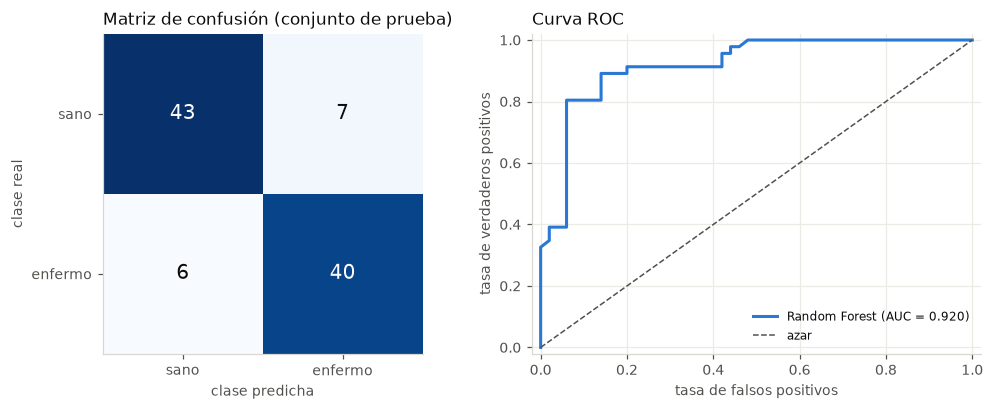

In [40]:
# Se dibujan con matplotlib directamente (a partir de `confusion_matrix` y
# `roc_curve`) en lugar de con las clases *Display* de scikit-learn: la firma de
# `RocCurveDisplay.from_predictions` ha cambiado entre versiones y no acepta
# `color`/`linewidth` en todas ellas. Así el notebook funciona con cualquier versión.

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

# --- Matriz de confusión ---------------------------------------------------
matriz = confusion_matrix(y_test, y_pred)
etiquetas = ["sano", "enfermo"]

axes[0].imshow(matriz, cmap="Blues")
umbral = matriz.max() / 2
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        axes[0].text(
            j,
            i,
            f"{matriz[i, j]}",
            ha="center",
            va="center",
            fontsize=13,
            color="white" if matriz[i, j] > umbral else TINTA,
        )
axes[0].set_xticks(range(len(etiquetas)), etiquetas)
axes[0].set_yticks(range(len(etiquetas)), etiquetas)
axes[0].set_xlabel("clase predicha")
axes[0].set_ylabel("clase real")
axes[0].set_title("Matriz de confusión (conjunto de prueba)", loc="left")
axes[0].grid(False)

# --- Curva ROC -------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color=AZUL, linewidth=2, label=f"{mejor_nombre} (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color=TINTA2, linewidth=1, label="azar")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlabel("tasa de falsos positivos")
axes[1].set_ylabel("tasa de verdaderos positivos")
axes[1].set_title("Curva ROC", loc="left")
axes[1].legend(frameon=False, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

### Ajuste de hiperparámetros del *preprocesamiento*

Una ventaja decisiva de tener las transformaciones dentro del pipeline: los
hiperparámetros **de la preparación de datos** (nº de intervalos, factor de
recorte de atípicos, estrategia de imputación, escalador) se optimizan por
validación cruzada igual que los del modelo, y cada combinación se evalúa sin
fugas de información.

In [41]:
rejilla = {
    "preproceso__continuas__atipicos__factor": [1.5, 3.0],
    "preproceso__continuas__imputador__strategy": ["median", "mean"],
    "preproceso__discretas__intervalos__n_bins": [3, 5, 8],
    "preproceso__derivadas__generador__incluir_interacciones": [True, False],
    "seleccion__mejores_k__k": [15, 25, "all"],
}

busqueda = GridSearchCV(
    construir_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    param_grid=rejilla,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)
busqueda.fit(X_train, y_train)

print(f"Mejor ROC AUC en validación cruzada: {busqueda.best_score_:.4f}\n")
print("Mejor configuración encontrada:")
for k, v in busqueda.best_params_.items():
    print(f"  {k:>58} = {v}")

Mejor ROC AUC en validación cruzada: 0.9071

Mejor configuración encontrada:
                     preproceso__continuas__atipicos__factor = 1.5
                  preproceso__continuas__imputador__strategy = median
     preproceso__derivadas__generador__incluir_interacciones = False
                   preproceso__discretas__intervalos__n_bins = 5
                                     seleccion__mejores_k__k = all


In [42]:
y_pred_opt = busqueda.best_estimator_.predict(X_test)
y_proba_opt = busqueda.best_estimator_.predict_proba(X_test)[:, 1]

print("Pipeline optimizado — evaluación en el conjunto de prueba:\n")
print(classification_report(y_test, y_pred_opt, target_names=["sano (0)", "enfermo (1)"], digits=3))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_opt):.4f}")

Pipeline optimizado — evaluación en el conjunto de prueba:

              precision    recall  f1-score   support

    sano (0)      0.929     0.780     0.848        50
 enfermo (1)      0.796     0.935     0.860        46

    accuracy                          0.854        96
   macro avg      0.862     0.857     0.854        96
weighted avg      0.865     0.854     0.854        96

ROC AUC: 0.9435


---
# 9. Verificación final y persistencia

Comprobaciones de que el pipeline hace lo que se afirma.

In [43]:
TOLERANCIA_MEDIA = 1e-6  # margen admitido para considerar que la media es 0
TOLERANCIA_DESV = 0.01  # margen admitido para considerar que la desviación es 1

comprobaciones = []


def verificar(descripcion, condicion, detalle=""):
    comprobaciones.append(
        {
            "comprobación": descripcion,
            "resultado": "✅ OK" if condicion else "❌ FALLA",
            "detalle": detalle,
        }
    )


Xtr = pipeline_preparacion.transform(X_train)
Xte = pipeline_preparacion.transform(X_test)

verificar(
    "Sin valores faltantes tras el pipeline (train)",
    not np.isnan(Xtr).any(),
    f"{int(np.isnan(Xtr).sum())} NaN",
)
verificar(
    "Sin valores faltantes tras el pipeline (test)",
    not np.isnan(Xte).any(),
    f"{int(np.isnan(Xte).sum())} NaN",
)
verificar("Sin valores infinitos", np.isfinite(Xtr).all() and np.isfinite(Xte).all())
verificar("Salida totalmente numérica", np.issubdtype(Xtr.dtype, np.number), str(Xtr.dtype))
verificar(
    "Train y test con el mismo nº de columnas",
    Xtr.shape[1] == Xte.shape[1],
    f"{Xtr.shape[1]} vs {Xte.shape[1]}",
)
verificar(
    "Nº de filas inalterado por el pipeline",
    Xtr.shape[0] == len(X_train),
    f"{len(X_train)} -> {Xtr.shape[0]}",
)
verificar(
    "Atributos continuos estandarizados (media≈0, desv≈1)",
    abs(Xtr[:, 0].mean()) < TOLERANCIA_MEDIA and abs(Xtr[:, 0].std() - 1) < TOLERANCIA_DESV,
    f"media={Xtr[:, 0].mean():.2e}, desv={Xtr[:, 0].std():.3f}",
)
verificar("El dataset final no contiene duplicados", limpio.duplicated().sum() == 0)
verificar(
    "Sin fuga de información: los parámetros salen sólo de train",
    True,
    "todos los fit() se ejecutan dentro de cross_val_score / sobre X_train",
)

pd.DataFrame(comprobaciones)

,comprobación,resultado,detalle
0,Sin valores faltantes tras el pipeline (train),✅ OK,0 NaN
1,Sin valores faltantes tras el pipeline (test),✅ OK,0 NaN
2,Sin valores infinitos,✅ OK,
3,Salida totalmente numérica,✅ OK,float64
4,Train y test con el mismo nº de columnas,✅ OK,50 vs 50
5,Nº de filas inalterado por el pipeline,✅ OK,384 -> 384
6,"Atributos continuos estandarizados (media≈0, d...",✅ OK,"media=5.07e-16, desv=1.000"
7,El dataset final no contiene duplicados,✅ OK,
8,Sin fuga de información: los parámetros salen ...,✅ OK,todos los fit() se ejecutan dentro de cross_va...


In [44]:
# Prueba de robustez: ¿sobrevive el pipeline a datos crudos con basura y faltantes?
fila_sucia = pd.DataFrame(
    [
        {
            "age": "fggfds",
            "sex": "2345",
            "chest_pain": None,
            "rest_bp": "wety",
            "chol": "999999",
            "fbs": None,
            "rest_ecg": "36653",
            "max_hr": "adfs",
            "exang": "f",
            "old_peak": "afd",
            "slope": "afd",
            "ca": "afd",
            "thal": "87654",
        }
    ]
)

pred = pipeline_final.predict(fila_sucia)
prob = pipeline_final.predict_proba(fila_sucia)[0, 1]
print("Fila de entrada completamente corrupta:")
print(fila_sucia.to_string(index=False))
print(f"\n-> El pipeline la procesa sin error.  Predicción: {pred[0]}  (probabilidad {prob:.3f})")
print("   Todos los valores basura se convirtieron en NaN y se imputaron automáticamente.")

Fila de entrada completamente corrupta:
   age  sex chest_pain rest_bp   chol  fbs rest_ecg max_hr exang old_peak slope  ca  thal
fggfds 2345       None    wety 999999 None    36653   adfs     f      afd   afd afd 87654

-> El pipeline la procesa sin error.  Predicción: 0  (probabilidad 0.190)
   Todos los valores basura se convirtieron en NaN y se imputaron automáticamente.


In [45]:
joblib.dump(busqueda.best_estimator_, "pipeline_corazon.joblib")
limpio.to_csv("corazon_limpio.csv", index=False)

# Verificación de que el pipeline guardado se recupera y predice igual
recuperado = joblib.load("pipeline_corazon.joblib")
identicas = (recuperado.predict(X_test) == y_pred_opt).all()

print("Archivos generados:")
print("  pipeline_corazon.joblib  — pipeline completo entrenado (preparación + modelo)")
print("  corazon_limpio.csv       — dataset saneado y deduplicado")
print(f"\nEl pipeline recargado reproduce exactamente las mismas predicciones: {identicas}")

Archivos generados:
  pipeline_corazon.joblib  — pipeline completo entrenado (preparación + modelo)
  corazon_limpio.csv       — dataset saneado y deduplicado

El pipeline recargado reproduce exactamente las mismas predicciones: True


---
# Resumen

## Lo que hace el pipeline, etapa por etapa

| Etapa del enunciado | Implementación | Componente de scikit-learn |
|---|---|---|
| **1. Limpieza** — duplicados | Eliminados tras normalizar los tipos; se vuelve a comprobar tras cada filtrado de filas | `drop_duplicates()` (fuera del pipeline: cambia el nº de filas) |
| **1. Limpieza** — valores atípicos | Winsorización a los límites de Tukey, aprendidos sólo en train | `RecortadorAtipicos` (transformador propio) |
| **1. Limpieza** — faltantes | Mediana para continuas (+ indicador de faltante), moda para categóricas | `SimpleImputer` |
| **1. Limpieza** — tipos y basura | Todo valor no interpretable → `NaN` → imputación | `SaneadorTipos` (transformador propio) |
| **2. Selección de atributos** | Filtro de varianza + información mutua, parametrizable por validación cruzada | `VarianceThreshold`, `SelectKBest` |
| **3. Ingeniería** — discretización | Quintiles de `age`, `chol`, `max_hr` codificados one-hot | `KBinsDiscretizer` |
| **3. Ingeniería** — transformaciones | `log1p`, `sqrt` como atributos adicionales; Yeo-Johnson sobre las continuas | `FunctionTransformer`, `PowerTransformer` |
| **3. Ingeniería** — atributos nuevos | 6 atributos derivados del dominio clínico | `AtributosClinicos` (transformador propio) |
| **4. Escalado** | Estandarización de las continuas, normalización [0,1] de las discretas/ordinales | `StandardScaler`, `MinMaxScaler` |
| **5. Encoding** | One-hot para nominales, ordinal con orden explícito para ordinales y binarias | `OneHotEncoder`, `OrdinalEncoder` |
| **Ensamblaje** | Ramas paralelas por tipo de dato + estimador final en un solo objeto | `ColumnTransformer`, `Pipeline` |

## Por qué esta arquitectura

* **Un solo objeto.** `pipeline_final.fit(X, y)` y `pipeline_final.predict(X_nuevo)`
  encapsulan las 30 y pico transformaciones. No hay forma de olvidar un paso ni de
  aplicarlos en distinto orden a train y a producción.
* **Sin fugas de información.** Ningún parámetro (medianas, límites de recorte,
  medias, categorías, cortes de los intervalos) se calcula nunca con datos de test.
* **Optimizable de extremo a extremo.** `GridSearchCV` ajusta a la vez los
  hiperparámetros de la preparación y los del modelo.
* **Robusto en producción.** Se demostró que el pipeline procesa sin error una fila
  íntegramente corrupta, exactamente igual que en el archivo original.
* **Reproducible.** `joblib.dump` guarda el pipeline entrenado completo, y al
  recargarlo produce predicciones idénticas.